In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data/processed/master_raw.csv")

In [4]:
df.head(5)

,Date,Strike,Expiry,OptionType,OI,Volume,SettlementPrice
0,2024-01-01,21400.0,2024-02-29,CE,20450,160,882.85
1,2024-01-01,21400.0,2024-03-28,PE,1400,33,322.15
2,2024-01-01,21400.0,2024-02-01,CE,450,1,772.55
3,2024-01-01,21400.0,2024-02-01,PE,1700,52,159.90
4,2024-01-01,21400.0,2024-01-11,PE,554900,34512,61.40


In [6]:
import yfinance as yf

# Nifty spot price
nifty = yf.download("^NSEI", start="2024-01-01", end="2024-06-01")
nifty.to_csv("data/raw/nifty_spot.csv")
print("Nifty saved:", nifty.shape)
print(nifty.tail(3))

# India VIX
vix = yf.download("^INDIAVIX", start="2024-01-01", end="2024-06-01")
vix.to_csv("data/raw/india_vix.csv")
print("VIX saved:", vix.shape)
print(vix.tail(3))

[*********************100%***********************]  1 of 1 completed


Nifty saved: (101, 5)
Price              Close      High           Low          Open  Volume
Ticker             ^NSEI     ^NSEI         ^NSEI         ^NSEI   ^NSEI
Date                                                                  
2024-05-29  22704.699219  22825.50  22685.449219  22762.750000  269900
2024-05-30  22488.650391  22705.75  22417.000000  22617.449219  373400
2024-05-31  22530.699219  22653.75  22465.099609  22568.099609  572100


[*********************100%***********************]  1 of 1 completed

VIX saved: (99, 5)
Price          Close       High        Low       Open    Volume
Ticker     ^INDIAVIX  ^INDIAVIX  ^INDIAVIX  ^INDIAVIX ^INDIAVIX
Date                                                           
2024-05-29     24.18  24.770000  23.549999  24.200001         0
2024-05-30     24.18  24.520000  22.750000  24.180000         0
2024-05-31     24.60  24.809999  22.600000  24.180000         0


In [7]:
nifty = pd.read_csv("data/raw/nifty_spot.csv")
vix = pd.read_csv("data/raw/india_vix.csv")

print("Options data:", df.shape)
print("Nifty columns:", nifty.columns.tolist())
print("VIX columns:", vix.columns.tolist())

Options data: (153249, 7)
Nifty columns: ['Price', 'Close', 'High', 'Low', 'Open', 'Volume']
VIX columns: ['Price', 'Close', 'High', 'Low', 'Open', 'Volume']


In [8]:
nifty.head(3)

,Price,Close,High,Low,Open,Volume
0,Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
1,Date,NaN,NaN,NaN,NaN,NaN
2,2024-01-01,21741.900390625,21834.349609375,21680.849609375,21727.75,154000


In [14]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# reload with correct column names assigned manually
nifty = pd.read_csv("data/raw/nifty_spot.csv", skiprows=2, 
                    names=["Date","Spot","High","Low","Open","Volume"])

vix   = pd.read_csv("data/raw/india_vix.csv", skiprows=2,
                    names=["Date","VIX","High","Low","Open","Volume"])

# keep only what we need
nifty = nifty[["Date", "Spot"]]
vix   = vix[["Date", "VIX"]]

# reload options data
df = pd.read_csv("data/processed/master_raw.csv")

# standardise date format
df["Date"]    = df["Date"].astype(str).str[:10]
nifty["Date"] = nifty["Date"].astype(str).str[:10]
vix["Date"]   = vix["Date"].astype(str).str[:10]

# merge
df = df.merge(nifty, on="Date", how="left")
df = df.merge(vix,   on="Date", how="left")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nNull check:")
print(df[["Spot", "VIX"]].isnull().sum())

Shape: (153249, 9)
Columns: ['Date', 'Strike', 'Expiry', 'OptionType', 'OI', 'Volume', 'SettlementPrice', 'Spot', 'VIX']

First 5 rows:
         Date   Strike      Expiry OptionType      OI  Volume  \
0  2024-01-01  21400.0  2024-02-29         CE   20450     160   
1  2024-01-01  21400.0  2024-03-28         PE    1400      33   
2  2024-01-01  21400.0  2024-02-01         CE     450       1   
3  2024-01-01  21400.0  2024-02-01         PE    1700      52   
4  2024-01-01  21400.0  2024-01-11         PE  554900   34512   

   SettlementPrice          Spot  VIX  
0           882.85  21741.900391  NaN  
1           322.15  21741.900391  NaN  
2           772.55  21741.900391  NaN  
3           159.90  21741.900391  NaN  
4            61.40  21741.900391  NaN  

Null check:
Spot       0
VIX     3009
dtype: int64


In [11]:
import pandas as pd

nifty = pd.read_csv("data/raw/nifty_spot.csv")
vix   = pd.read_csv("data/raw/india_vix.csv")

print("Nifty columns:", nifty.columns.tolist())
print("VIX columns:", vix.columns.tolist())
print("\nNifty first 3 rows:")
print(nifty.head(3))
print("\nVIX first 3 rows:")
print(vix.head(3))

Nifty columns: ['Price', 'Close', 'High', 'Low', 'Open', 'Volume']
VIX columns: ['Price', 'Close', 'High', 'Low', 'Open', 'Volume']

Nifty first 3 rows:
        Price            Close             High              Low      Open  \
0      Ticker            ^NSEI            ^NSEI            ^NSEI     ^NSEI   
1        Date              NaN              NaN              NaN       NaN   
2  2024-01-01  21741.900390625  21834.349609375  21680.849609375  21727.75   

   Volume  
0   ^NSEI  
1     NaN  
2  154000  

VIX first 3 rows:
        Price               Close                High                 Low  \
0      Ticker           ^INDIAVIX           ^INDIAVIX           ^INDIAVIX   
1        Date                 NaN                 NaN                 NaN   
2  2024-01-02  14.579999923706055  15.079999923706055  14.239999771118164   

                 Open     Volume  
0           ^INDIAVIX  ^INDIAVIX  
1                 NaN        NaN  
2  14.680000305175781          0  


In [13]:
import pandas as pd

nifty = pd.read_csv("data/raw/nifty_spot.csv", skiprows=2)
print("Columns after skiprows=2:", nifty.columns.tolist())
print(nifty.head(3))

Columns after skiprows=2: ['Date', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5']
         Date    Unnamed: 1    Unnamed: 2    Unnamed: 3    Unnamed: 4  \
0  2024-01-01  21741.900391  21834.349609  21680.849609  21727.750000   
1  2024-01-02  21665.800781  21755.599609  21555.650391  21751.349609   
2  2024-01-03  21517.349609  21677.000000  21500.349609  21661.099609   

   Unnamed: 5  
0      154000  
1      263700  
2      311900  


In [15]:
# check which dates have null VIX
null_vix_dates = df[df["VIX"].isnull()]["Date"].unique()
print("Dates with null VIX:", len(null_vix_dates))
print("Sample null dates:", null_vix_dates[:5])

# check if VIX has data at all
print("\nVIX non-null count:", df["VIX"].notna().sum())
print("VIX sample values:", df[df["VIX"].notna()]["VIX"].head(5).values)

Dates with null VIX: 2
Sample null dates: <StringArray>
['2024-01-01', '2024-02-19']
Length: 2, dtype: str

VIX non-null count: 150240
VIX sample values: [14.57999992 14.57999992 14.57999992 14.57999992 14.57999992]


In [16]:
# sort by date first
df = df.sort_values("Date").reset_index(drop=True)

# forward fill VIX
df["VIX"] = df["VIX"].ffill()
df["VIX"] = df["VIX"].bfill()

print("Null VIX after fill:", df["VIX"].isnull().sum())
print("Shape:", df.shape)

# save the merged dataframe
df.to_csv("data/processed/master_merged.csv", index=False)
print("\nSaved to data/processed/master_merged.csv")
print("\nSample dates with Spot and VIX:")
print(df[["Date","Spot","VIX"]].drop_duplicates("Date").head(10))

Null VIX after fill: 0
Shape: (153249, 9)

Saved to data/processed/master_merged.csv

Sample dates with Spot and VIX:
             Date          Spot    VIX
0      2024-01-01  21741.900391  14.58
1502   2024-01-02  21665.800781  14.58
3004   2024-01-03  21517.349609  14.10
4510   2024-01-04  21658.599609  13.33
6020   2024-01-05  21710.800781  12.63
7450   2024-01-08  21513.000000  13.46
8938   2024-01-09  21544.849609  13.26
10442  2024-01-10  21618.699219  12.97
11946  2024-01-11  21647.199219  12.77
13450  2024-01-12  21894.550781  13.10


In [17]:
import pandas as pd

df = pd.read_csv("data/processed/master_merged.csv")

df["Date"]   = pd.to_datetime(df["Date"])
df["Expiry"] = pd.to_datetime(df["Expiry"])

df["DTE"] = (df["Expiry"] - df["Date"]).dt.days

print("Shape:", df.shape)
print("DTE range:", df["DTE"].min(), "to", df["DTE"].max())
print("\nSample:")
print(df[["Date","Strike","Expiry","DTE","Spot","VIX"]].head(8))

Shape: (153249, 10)
DTE range: 0 to 1823

Sample:
        Date   Strike     Expiry  DTE          Spot    VIX
0 2024-01-01  21400.0 2024-02-29   59  21741.900391  14.58
1 2024-01-01  23100.0 2024-01-11   10  21741.900391  14.58
2 2024-01-01  23100.0 2024-02-01   31  21741.900391  14.58
3 2024-01-01  23100.0 2024-01-18   17  21741.900391  14.58
4 2024-01-01  20100.0 2024-01-11   10  21741.900391  14.58
5 2024-01-01  22600.0 2024-01-25   24  21741.900391  14.58
6 2024-01-01  23250.0 2024-02-01   31  21741.900391  14.58
7 2024-01-01  22600.0 2024-01-11   10  21741.900391  14.58


In [18]:
df = df[(df["DTE"] >= 1) & (df["DTE"] <= 90)]

print("Shape after DTE filter:", df.shape)
print("DTE range now:", df["DTE"].min(), "to", df["DTE"].max())
print("Rows removed:", 153249 - len(df))

Shape after DTE filter: (119620, 10)
DTE range now: 1 to 90
Rows removed: 33629


In [19]:
df["Moneyness"] = df["Strike"] / df["Spot"]

df = df[(df["Moneyness"] >= 0.90) & (df["Moneyness"] <= 1.10)]

print("Shape after moneyness filter:", df.shape)
print("Moneyness range:", round(df["Moneyness"].min(), 3), "to", round(df["Moneyness"].max(), 3))
print("Rows removed:", 119620 - len(df))
print("\nUnique strikes per day (avg):", round(df.groupby("Date")["Strike"].nunique().mean(), 1))
print("Unique expiries per day (avg):", round(df.groupby("Date")["Expiry"].nunique().mean(), 1))

Shape after moneyness filter: (110476, 11)
Moneyness range: 0.9 to 1.1
Rows removed: 9144

Unique strikes per day (avg): 84.0
Unique expiries per day (avg): 6.8


In [20]:
# rank expiries by DTE for each date — nearest = rank 1
df["ExpiryRank"] = df.groupby("Date")["DTE"].rank(method="dense")

# keep only nearest 4 expiries
df = df[df["ExpiryRank"] <= 4]

print("Shape after expiry filter:", df.shape)
print("Rows removed:", 110476 - len(df))
print("\nUnique expiries per day (avg):", round(df.groupby("Date")["Expiry"].nunique().mean(), 1))
print("Unique strikes per day (avg):", round(df.groupby("Date")["Strike"].nunique().mean(), 1))

# save
df.to_csv("data/processed/master_filtered.csv", index=False)
print("\nSaved to data/processed/master_filtered.csv")
print("Final shape:", df.shape)

Shape after expiry filter: (65938, 12)
Rows removed: 44538

Unique expiries per day (avg): 4.0
Unique strikes per day (avg): 83.7

Saved to data/processed/master_filtered.csv
Final shape: (65938, 12)


In [21]:
# reload filtered file
df = pd.read_csv("data/processed/master_filtered.csv")

# tighter moneyness — within 5% of spot instead of 10%
df["Moneyness"] = df["Strike"] / df["Spot"]
df = df[(df["Moneyness"] >= 0.95) & (df["Moneyness"] <= 1.05)]

print("Shape after tighter moneyness:", df.shape)
print("Unique strikes per day (avg):", round(df.groupby("Date")["Strike"].nunique().mean(), 1))
print("Unique expiries per day (avg):", round(df.groupby("Date")["Expiry"].nunique().mean(), 1))
print("Moneyness range:", round(df["Moneyness"].min(), 3), "to", round(df["Moneyness"].max(), 3))

# save
df.to_csv("data/processed/master_filtered.csv", index=False)
print("\nSaved. Final shape:", df.shape)

Shape after tighter moneyness: (35784, 12)
Unique strikes per day (avg): 44.3
Unique expiries per day (avg): 4.0
Moneyness range: 0.95 to 1.05

Saved. Final shape: (35784, 12)


In [23]:
pip install scipy

                                              0.0/36.6 MB ? eta -:--:--
                                              0.7/36.6 MB 15.0 MB/s eta 0:00:03
     -                                        1.3/36.6 MB 16.0 MB/s eta 0:00:03
     --                                       1.9/36.6 MB 14.8 MB/s eta 0:00:03
     --                                       2.4/36.6 MB 15.4 MB/s eta 0:00:03
     --                                       2.5/36.6 MB 14.6 MB/s eta 0:00:03
     --                                       2.7/36.6 MB 11.5 MB/s eta 0:00:03
     ---                                      3.4/36.6 MB 12.8 MB/s eta 0:00:03
     ----                                     4.0/36.6 MB 12.8 MB/s eta 0:00:03
     ----                                     4.5/36.6 MB 13.1 MB/s eta 0:00:03
     -----                                    5.0/36.6 MB 13.4 MB/s eta 0:00:03
     ------                                   5.5/36.6 MB 13.6 MB/s eta 0:00:03
     ------                                   6.


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import numpy as np
from scipy.optimize import brentq
from scipy.stats import norm

def black_scholes_price(S, K, T, r, sigma, option_type):
    """
    S     = spot price
    K     = strike price  
    T     = time to expiry in years
    r     = risk free rate (use 0.065 for India)
    sigma = volatility (what we're solving for)
    option_type = CE or PE
    """
    if T <= 0 or sigma <= 0:
        return 0.0
    
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type == "CE":
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    
    return price


def compute_iv(S, K, T, r, market_price, option_type):
    """
    Finds the sigma that makes BS price = market price.
    Returns NaN if it can't find a solution.
    """
    if market_price <= 0.01 or T <= 0:
        return np.nan
    
    try:
        iv = brentq(
            lambda sigma: black_scholes_price(S, K, T, r, sigma, option_type) - market_price,
            a=0.001,   # minimum vol to try (0.1%)
            b=5.0,     # maximum vol to try (500%)
            xtol=1e-6,
            maxiter=100
        )
        return iv
    except:
        return np.nan


# test it on one row
S = 21700   # spot
K = 21500   # strike
T = 17/365  # 17 days to expiry
r = 0.065   # India risk free rate
market_price = 913.80  # settlement price from your data
option_type = "CE"

iv = compute_iv(S, K, T, r, market_price, option_type)
print(f"Computed IV: {iv:.4f} = {iv*100:.2f}%")
print("Expected: somewhere between 10% and 25% for Nifty")

Computed IV: 0.4170 = 41.70%
Expected: somewhere between 10% and 25% for Nifty


In [25]:
import pandas as pd
import numpy as np
from scipy.optimize import brentq
from scipy.stats import norm

df = pd.read_csv("data/processed/master_filtered.csv")

# convert T to years
df["T"] = df["DTE"] / 365

# apply IV computation row by row
def compute_iv(S, K, T, r, market_price, option_type):
    if market_price <= 0.01 or T <= 0:
        return np.nan
    try:
        iv = brentq(
            lambda sigma: black_scholes_price(S, K, T, r, sigma, option_type) - market_price,
            a=0.001, b=5.0, xtol=1e-6, maxiter=100
        )
        return iv
    except:
        return np.nan

def black_scholes_price(S, K, T, r, sigma, option_type):
    if T <= 0 or sigma <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == "CE":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

print("Computing IV for", len(df), "rows...")
print("This will take 5-10 minutes, please wait...\n")

df["IV"] = df.apply(
    lambda row: compute_iv(
        row["Spot"], row["Strike"], row["T"],
        0.065, row["SettlementPrice"], row["OptionType"]
    ), axis=1
)

print("Done.")
print("\nIV distribution:")
print(df["IV"].describe())
print("\nNull IVs:", df["IV"].isnull().sum())
print("Valid IVs:", df["IV"].notna().sum())

Computing IV for 35784 rows...
This will take 5-10 minutes, please wait...

Done.

IV distribution:
count    33900.000000
mean         0.154791
std          0.055885
min          0.028944
25%          0.124592
50%          0.140397
75%          0.160629
max          0.754099
Name: IV, dtype: float64

Null IVs: 1884
Valid IVs: 33900


In [26]:
# drop rows where IV failed
df_clean = df[df["IV"].notna()].copy()

# drop extreme IVs — below 5% or above 100% are unreliable
df_clean = df_clean[(df_clean["IV"] >= 0.05) & (df_clean["IV"] <= 1.0)]

print("Shape after IV cleaning:", df_clean.shape)
print("Rows dropped:", len(df) - len(df_clean))
print("\nIV distribution after cleaning:")
print(df_clean["IV"].describe().round(4))

# save
df_clean.to_csv("data/processed/master_with_iv.csv", index=False)
print("\nSaved to data/processed/master_with_iv.csv")

Shape after IV cleaning: (33893, 14)
Rows dropped: 1891

IV distribution after cleaning:
count    33893.0000
mean         0.1548
std          0.0559
min          0.0501
25%          0.1246
50%          0.1404
75%          0.1606
max          0.7541
Name: IV, dtype: float64

Saved to data/processed/master_with_iv.csv


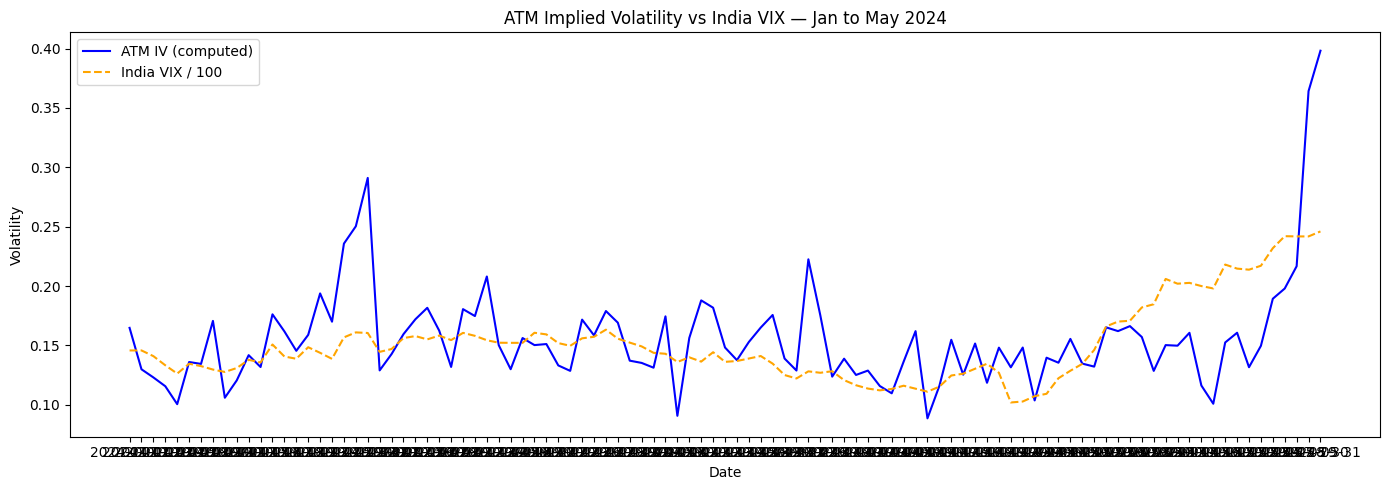

Chart saved.


In [27]:
import matplotlib.pyplot as plt

# get ATM IV per day — moneyness closest to 1.0, nearest expiry
atm_iv = df_clean[
    (df_clean["Moneyness"].between(0.98, 1.02)) &
    (df_clean["ExpiryRank"] == 1) &
    (df_clean["OptionType"] == "CE")
].groupby("Date")["IV"].median()

vix_daily = df_clean.groupby("Date")["VIX"].first() / 100

plt.figure(figsize=(14, 5))
plt.plot(atm_iv.index, atm_iv.values, label="ATM IV (computed)", color="blue")
plt.plot(vix_daily.index, vix_daily.values, label="India VIX / 100", color="orange", linestyle="--")
plt.title("ATM Implied Volatility vs India VIX — Jan to May 2024")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.tight_layout()
plt.savefig("data/processed/atm_iv_vs_vix.png")
plt.show()
print("Chart saved.")

In [28]:
print("master_with_iv.csv shape:", df_clean.shape)
print("IV range:", round(df_clean["IV"].min(),3), "to", round(df_clean["IV"].max(),3))
print("Dates:", df_clean["Date"].min(), "to", df_clean["Date"].max())
print("\nDay 3 complete. Moving to Day 4 - building the surface grid.")

master_with_iv.csv shape: (33893, 14)
IV range: 0.05 to 0.754
Dates: 2024-01-01 to 2024-05-31

Day 3 complete. Moving to Day 4 - building the surface grid.


In [29]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/processed/master_with_iv.csv")

print("Loaded:", df.shape)

# moneyness buckets — 5 groups
df["MBucket"] = pd.cut(
    df["Moneyness"],
    bins  = [0.95, 0.97, 0.99, 1.01, 1.03, 1.05],
    labels= ["M1","M2","M3","M4","M5"]
)

# DTE buckets — 4 groups
df["DBucket"] = pd.cut(
    df["DTE"],
    bins  = [0, 15, 30, 60, 90],
    labels= ["D1","D2","D3","D4"]
)

print("Moneyness buckets:")
print(df["MBucket"].value_counts().sort_index())
print("\nDTE buckets:")
print(df["DBucket"].value_counts().sort_index())

Loaded: (33893, 14)
Moneyness buckets:
MBucket
M1    6885
M2    7009
M3    7136
M4    6648
M5    6215
Name: count, dtype: int64

DTE buckets:
DBucket
D1    17856
D2    16037
D3        0
D4        0
Name: count, dtype: int64


In [33]:
# check actual DTE distribution
print("DTE distribution:")
print(df["DTE"].describe())
print("\nDTE value counts (sample):")
print(df["DTE"].value_counts().sort_index().head(20))

DTE distribution:
count    33893.000000
mean        14.782787
std          8.053460
min          1.000000
25%          8.000000
50%         15.000000
75%         22.000000
max         29.000000
Name: DTE, dtype: float64

DTE value counts (sample):
DTE
1     1420
2     1626
3     1350
5       82
6     1496
7     1608
8     1637
9     1846
10    1542
13    1724
14    1790
15    1735
16    1841
17    1672
19      87
20    1678
21    1844
22    1758
23    1948
24    1583
Name: count, dtype: int64


In [34]:
# DTE buckets fitted to actual data range (1-29 days)
df["DBucket"] = pd.cut(
    df["DTE"],
    bins  = [0, 7, 14, 21, 30],
    labels= ["D1","D2","D3","D4"]
)

# moneyness buckets same as before
df["MBucket"] = pd.cut(
    df["Moneyness"],
    bins  = [0.95, 0.97, 0.99, 1.01, 1.03, 1.05],
    labels= ["M1","M2","M3","M4","M5"]
)

print("DTE buckets:")
print(df["DBucket"].value_counts().sort_index())
print("\nMoneyness buckets:")
print(df["MBucket"].value_counts().sort_index())

DTE buckets:
DBucket
D1    7582
D2    8539
D3    8857
D4    8915
Name: count, dtype: int64

Moneyness buckets:
MBucket
M1    6885
M2    7009
M3    7136
M4    6648
M5    6215
Name: count, dtype: int64


In [35]:
df["Node"] = df["OptionType"] + "_" + df["MBucket"].astype(str) + "_" + df["DBucket"].astype(str)

print("Sample nodes:")
print(df["Node"].value_counts().head(10))
print("\nTotal unique nodes:", df["Node"].nunique())

Sample nodes:
Node
CE_M4_D4    896
PE_M4_D4    896
PE_M3_D3    896
CE_M3_D3    896
CE_M3_D4    895
PE_M2_D1    895
PE_M2_D2    895
PE_M1_D2    895
CE_M4_D1    895
PE_M2_D3    895
Name: count, dtype: int64

Total unique nodes: 40


In [36]:
surface = df.groupby(["Date","Node"])["IV"].median().reset_index()

surface_wide = surface.pivot(index="Date", columns="Node", values="IV")

print("Surface grid shape:", surface_wide.shape)
print("Rows (days):", surface_wide.shape[0])
print("Columns (surface nodes):", surface_wide.shape[1])
print("\nColumn names:")
print(surface_wide.columns.tolist())
print("\nFirst 3 rows:")
print(surface_wide.head(3).round(4))

Surface grid shape: (101, 40)
Rows (days): 101
Columns (surface nodes): 40

Column names:
['CE_M1_D1', 'CE_M1_D2', 'CE_M1_D3', 'CE_M1_D4', 'CE_M2_D1', 'CE_M2_D2', 'CE_M2_D3', 'CE_M2_D4', 'CE_M3_D1', 'CE_M3_D2', 'CE_M3_D3', 'CE_M3_D4', 'CE_M4_D1', 'CE_M4_D2', 'CE_M4_D3', 'CE_M4_D4', 'CE_M5_D1', 'CE_M5_D2', 'CE_M5_D3', 'CE_M5_D4', 'PE_M1_D1', 'PE_M1_D2', 'PE_M1_D3', 'PE_M1_D4', 'PE_M2_D1', 'PE_M2_D2', 'PE_M2_D3', 'PE_M2_D4', 'PE_M3_D1', 'PE_M3_D2', 'PE_M3_D3', 'PE_M3_D4', 'PE_M4_D1', 'PE_M4_D2', 'PE_M4_D3', 'PE_M4_D4', 'PE_M5_D1', 'PE_M5_D2', 'PE_M5_D3', 'PE_M5_D4']

First 3 rows:
Node        CE_M1_D1  CE_M1_D2  CE_M1_D3  CE_M1_D4  CE_M2_D1  CE_M2_D2  \
Date                                                                     
2024-01-01    0.3651    0.2110    0.1277    0.1998    0.2319    0.1814   
2024-01-02    0.3164    0.1340    0.1295    0.1481    0.1263    0.1347   
2024-01-03    0.2656    0.1399    0.1280    0.1432       NaN    0.1233   

Node        CE_M2_D3  CE_M2_D4  CE_M3_D1  C

In [37]:
daily_context = df.groupby("Date")[["Spot","VIX"]].first()

surface_wide = surface_wide.merge(daily_context, on="Date", how="left")

surface_wide = surface_wide.ffill().bfill()

print("Shape after adding Spot and VIX:", surface_wide.shape)
print("Null values:", surface_wide.isnull().sum().sum())

surface_wide.to_csv("data/processed/surface_panel.csv")
print("\nSaved to data/processed/surface_panel.csv")
print("Final shape:", surface_wide.shape)
print("\nSample:")
print(surface_wide.head(3).round(4))

Shape after adding Spot and VIX: (101, 42)
Null values: 0

Saved to data/processed/surface_panel.csv
Final shape: (101, 42)

Sample:
            CE_M1_D1  CE_M1_D2  CE_M1_D3  CE_M1_D4  CE_M2_D1  CE_M2_D2  \
Date                                                                     
2024-01-01    0.3651    0.2110    0.1277    0.1998    0.2319    0.1814   
2024-01-02    0.3164    0.1340    0.1295    0.1481    0.1263    0.1347   
2024-01-03    0.2656    0.1399    0.1280    0.1432    0.1263    0.1233   

            CE_M2_D3  CE_M2_D4  CE_M3_D1  CE_M3_D2  ...  PE_M4_D1  PE_M4_D2  \
Date                                                ...                       
2024-01-01    0.1253    0.1786    0.1648    0.1506  ...    0.2078    0.0794   
2024-01-02    0.1379    0.1490    0.1295    0.1306  ...    0.2078    0.1263   
2024-01-03    0.1337    0.1407    0.1129    0.1170  ...    0.2960    0.1315   

            PE_M4_D3  PE_M4_D4  PE_M5_D1  PE_M5_D2  PE_M5_D3  PE_M5_D4  \
Date                      

In [38]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd

surface_wide = pd.read_csv("data/processed/surface_panel.csv", index_col="Date")

# pick one day
date = "2024-03-15"
row = surface_wide.loc[date]

# separate CE surface
ce_cols = [c for c in surface_wide.columns if c.startswith("CE")]
pe_cols = [c for c in surface_wide.columns if c.startswith("PE")]

# reshape CE into 5x4 grid (moneyness x DTE)
ce_values = row[ce_cols].values.reshape(5, 4)
pe_values = row[pe_cols].values.reshape(5, 4)

moneyness_labels = ["M1\n(deep ITM)", "M2", "M3\n(ATM)", "M4", "M5\n(deep OTM)"]
dte_labels        = ["D1\n(1-7d)", "D2\n(8-14d)", "D3\n(15-21d)", "D4\n(22-30d)"]

fig = go.Figure(data=[
    go.Surface(
        z=ce_values,
        colorscale="Blues",
        name="CE",
        showscale=True,
        opacity=0.85
    )
])

fig.update_layout(
    title=f"Nifty Implied Volatility Surface — {date} (Call options)",
    scene=dict(
        xaxis_title="DTE bucket",
        yaxis_title="Moneyness bucket",
        zaxis_title="Implied Volatility"
    ),
    width=800,
    height=600
)

fig.write_html("data/processed/surface_plot.html")
fig.show()
print("Saved to data/processed/surface_plot.html")
print("Open this file in your browser for interactive 3D view")

Saved to data/processed/surface_plot.html
Open this file in your browser for interactive 3D view
